In [3]:
import pandas as pd

df = pd.read_parquet("/app/datamart/gold/model_predictions/champion_model/champion_model_predictions_2024_07_01.parquet")

df.to_csv("/app/datamart/gold/model_predictions/champion_model_predictions_2024_07_01.csv", index=False)

print("Saved CSV")

Saved CSV


In [2]:
import os

path = "/app/datamart/gold/model_predictions"

print(os.listdir(path))

['champion_model']


In [5]:
df = pd.read_parquet(
    "/app/datamart/gold/model_predictions/champion_model/champion_model_predictions_2024_07_01.parquet"
)

print(df.columns.tolist())
df.head()

['Customer_ID', 'snapshot_date', 'model_name', 'model_version', 'pred_proba', 'pred_label']


,Customer_ID,snapshot_date,model_name,model_version,pred_proba,pred_label
0,cus_0x1108,2024-07-01,xgboost,credit_model_xgboost_2026_06_20,0.279423,0
1,cus_0x13b5,2024-07-01,xgboost,credit_model_xgboost_2026_06_20,0.210142,0
2,cus_0x13b8,2024-07-01,xgboost,credit_model_xgboost_2026_06_20,0.206143,0
3,cus_0x144f,2024-07-01,xgboost,credit_model_xgboost_2026_06_20,0.906251,1
4,cus_0x14ec,2024-07-01,xgboost,credit_model_xgboost_2026_06_20,0.347514,0


In [6]:
import pandas as pd
import glob
import os


prediction_files = sorted(
    glob.glob(
        "/app/datamart/gold/model_predictions/champion_model/*.parquet"
    )
)

summary = []


for file in prediction_files:

    df = pd.read_parquet(file)

    month = os.path.basename(file) \
              .replace("champion_model_predictions_", "") \
              .replace(".parquet", "")

    total_customers = len(df)

    avg_pd = df["pred_proba"].mean()

    predicted_default_rate = (
        df["pred_label"].mean()
    )

    predicted_defaults = (
        df["pred_label"] == 1
    ).sum()

    summary.append({
        "snapshot_month": month,
        "customers_scored": total_customers,
        "avg_pd": round(avg_pd * 100, 2),
        "predicted_default_rate": round(predicted_default_rate * 100, 2),
        "predicted_defaults": predicted_defaults
    })


monthly_summary = pd.DataFrame(summary)

monthly_summary

,snapshot_month,customers_scored,avg_pd,predicted_default_rate,predicted_defaults
0,2024_07_01,505,42.17,37.03,187
1,2024_08_01,543,41.60,34.99,190
2,2024_09_01,493,41.98,37.53,185
3,2024_10_01,456,39.16,30.04,137
4,2024_11_01,488,41.75,35.66,174
5,2024_12_01,515,37.57,28.54,147


In [11]:
import pandas as pd

df_m = pd.read_parquet("/app/datamart/gold/model_monitoring/model_monitoring.parquet")
df_m

,snapshot_date,row_count,actual_default_rate,predicted_default_rate,avg_pred_proba,accuracy,precision,recall,f1,roc_auc,...,pred_proba_mean,pred_proba_std,pred_proba_p10,pred_proba_p50,pred_proba_p90,prediction_psi_vs_baseline,baseline_month,monitoring_run_date,retrain_flag,governance_reason
0,2024-07-01,505,0.306931,0.370297,0.421697,0.770297,0.604278,0.729032,0.660819,0.848350,...,0.421697,0.286317,0.108471,0.312817,0.857456,0.000000,2024-07-01,2026-06-20 04:03:44,0,Model healthy
1,2024-08-01,543,0.300184,0.349908,0.415988,0.777164,0.610526,0.711656,0.657224,0.811673,...,0.415988,0.273345,0.114726,0.319500,0.850821,0.023944,2024-07-01,2026-06-20 04:03:44,0,Model healthy
2,2024-09-01,493,0.330629,0.375254,0.419769,0.772819,0.637838,0.723926,0.678161,0.826957,...,0.419769,0.281084,0.077856,0.318548,0.848405,0.053620,2024-07-01,2026-06-20 04:03:44,0,Model healthy
3,2024-10-01,456,0.245614,0.300439,0.391564,0.804825,0.583942,0.714286,0.642570,0.841544,...,0.391564,0.264738,0.111856,0.292311,0.831438,0.048044,2024-07-01,2026-06-20 04:03:44,0,Model healthy
4,2024-11-01,488,0.280738,0.356557,0.417515,0.788934,0.597701,0.759124,0.668810,0.841828,...,0.417515,0.274895,0.118372,0.320836,0.847761,0.025997,2024-07-01,2026-06-20 04:03:44,0,Model healthy
5,2024-12-01,515,0.271845,0.285437,0.375712,0.815534,0.653061,0.685714,0.668990,0.857771,...,0.375712,0.261478,0.080873,0.285589,0.819502,0.058652,2024-07-01,2026-06-20 04:03:44,0,Model healthy


In [9]:
import os

path = "/app/datamart/gold/model_monitoring"

print(os.listdir(path))

['model_monitoring.csv', 'model_monitoring.parquet']


In [12]:
df_m["roc_auc"]

0    0.848350
1    0.811673
2    0.826957
3    0.841544
4    0.841828
5    0.857771
Name: roc_auc, dtype: float64

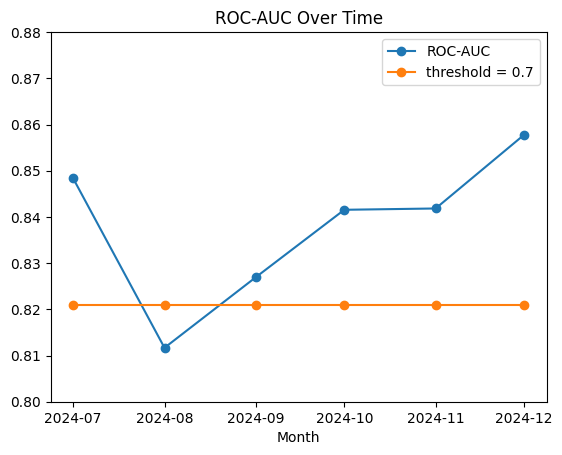

In [32]:
import matplotlib.pyplot as plt
import numpy as np

roc_auc = df_m["roc_auc"]
month = df_m["snapshot_date"]
threshold = [0.821,0.821,0.821,0.821,0.821,0.821]

plt.plot(month, roc_auc, marker='o', label="ROC-AUC")
plt.plot(month, threshold, marker='o', label="threshold = 0.7")

plt.ylim(0.80, 0.88)
plt.title('ROC-AUC Over Time')
plt.xlabel('Month')
# plt.ylabel('roc_auc')
plt.legend()
# plt.grid(True, alpha=0.3)
plt.show()

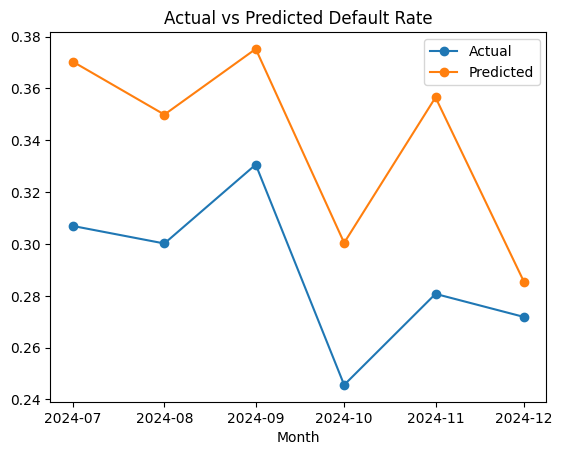

In [33]:
actual_default_rate = df_m["actual_default_rate"]
predicted_default_rate = df_m["predicted_default_rate"]
month = df_m["snapshot_date"]

plt.plot(month, actual_default_rate, marker='o', label = "Actual")
plt.plot(month, predicted_default_rate, marker='o', label = "Predicted")
plt.title('Actual vs Predicted Default Rate')
plt.xlabel('Month')
# plt.ylabel('roc_auc')
plt.legend()
plt.show()

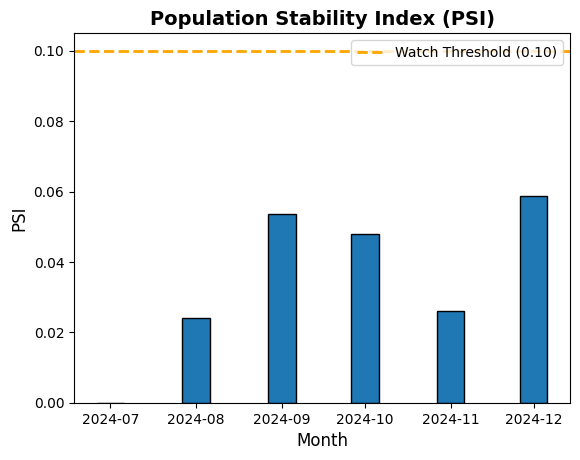

In [41]:
psi = df_m["prediction_psi_vs_baseline"]
month = df_m["snapshot_date"]

plt.bar(month, psi, edgecolor='black', width=10)

plt.title('Population Stability Index (PSI)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('PSI', fontsize=12)

plt.axhline(
    y=0.10,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Watch Threshold (0.10)"
)

plt.legend()